In [ ]:
# CELL 1: Run this cell first to upload your CSV file
from google.colab import files

print("Please upload your 'credit_card_fraud_10k.csv' file:")
uploaded = files.upload()

Please upload your 'credit_card_fraud_10k.csv' file:


Saving credit_card_fraud_10k.csv to credit_card_fraud_10k.csv


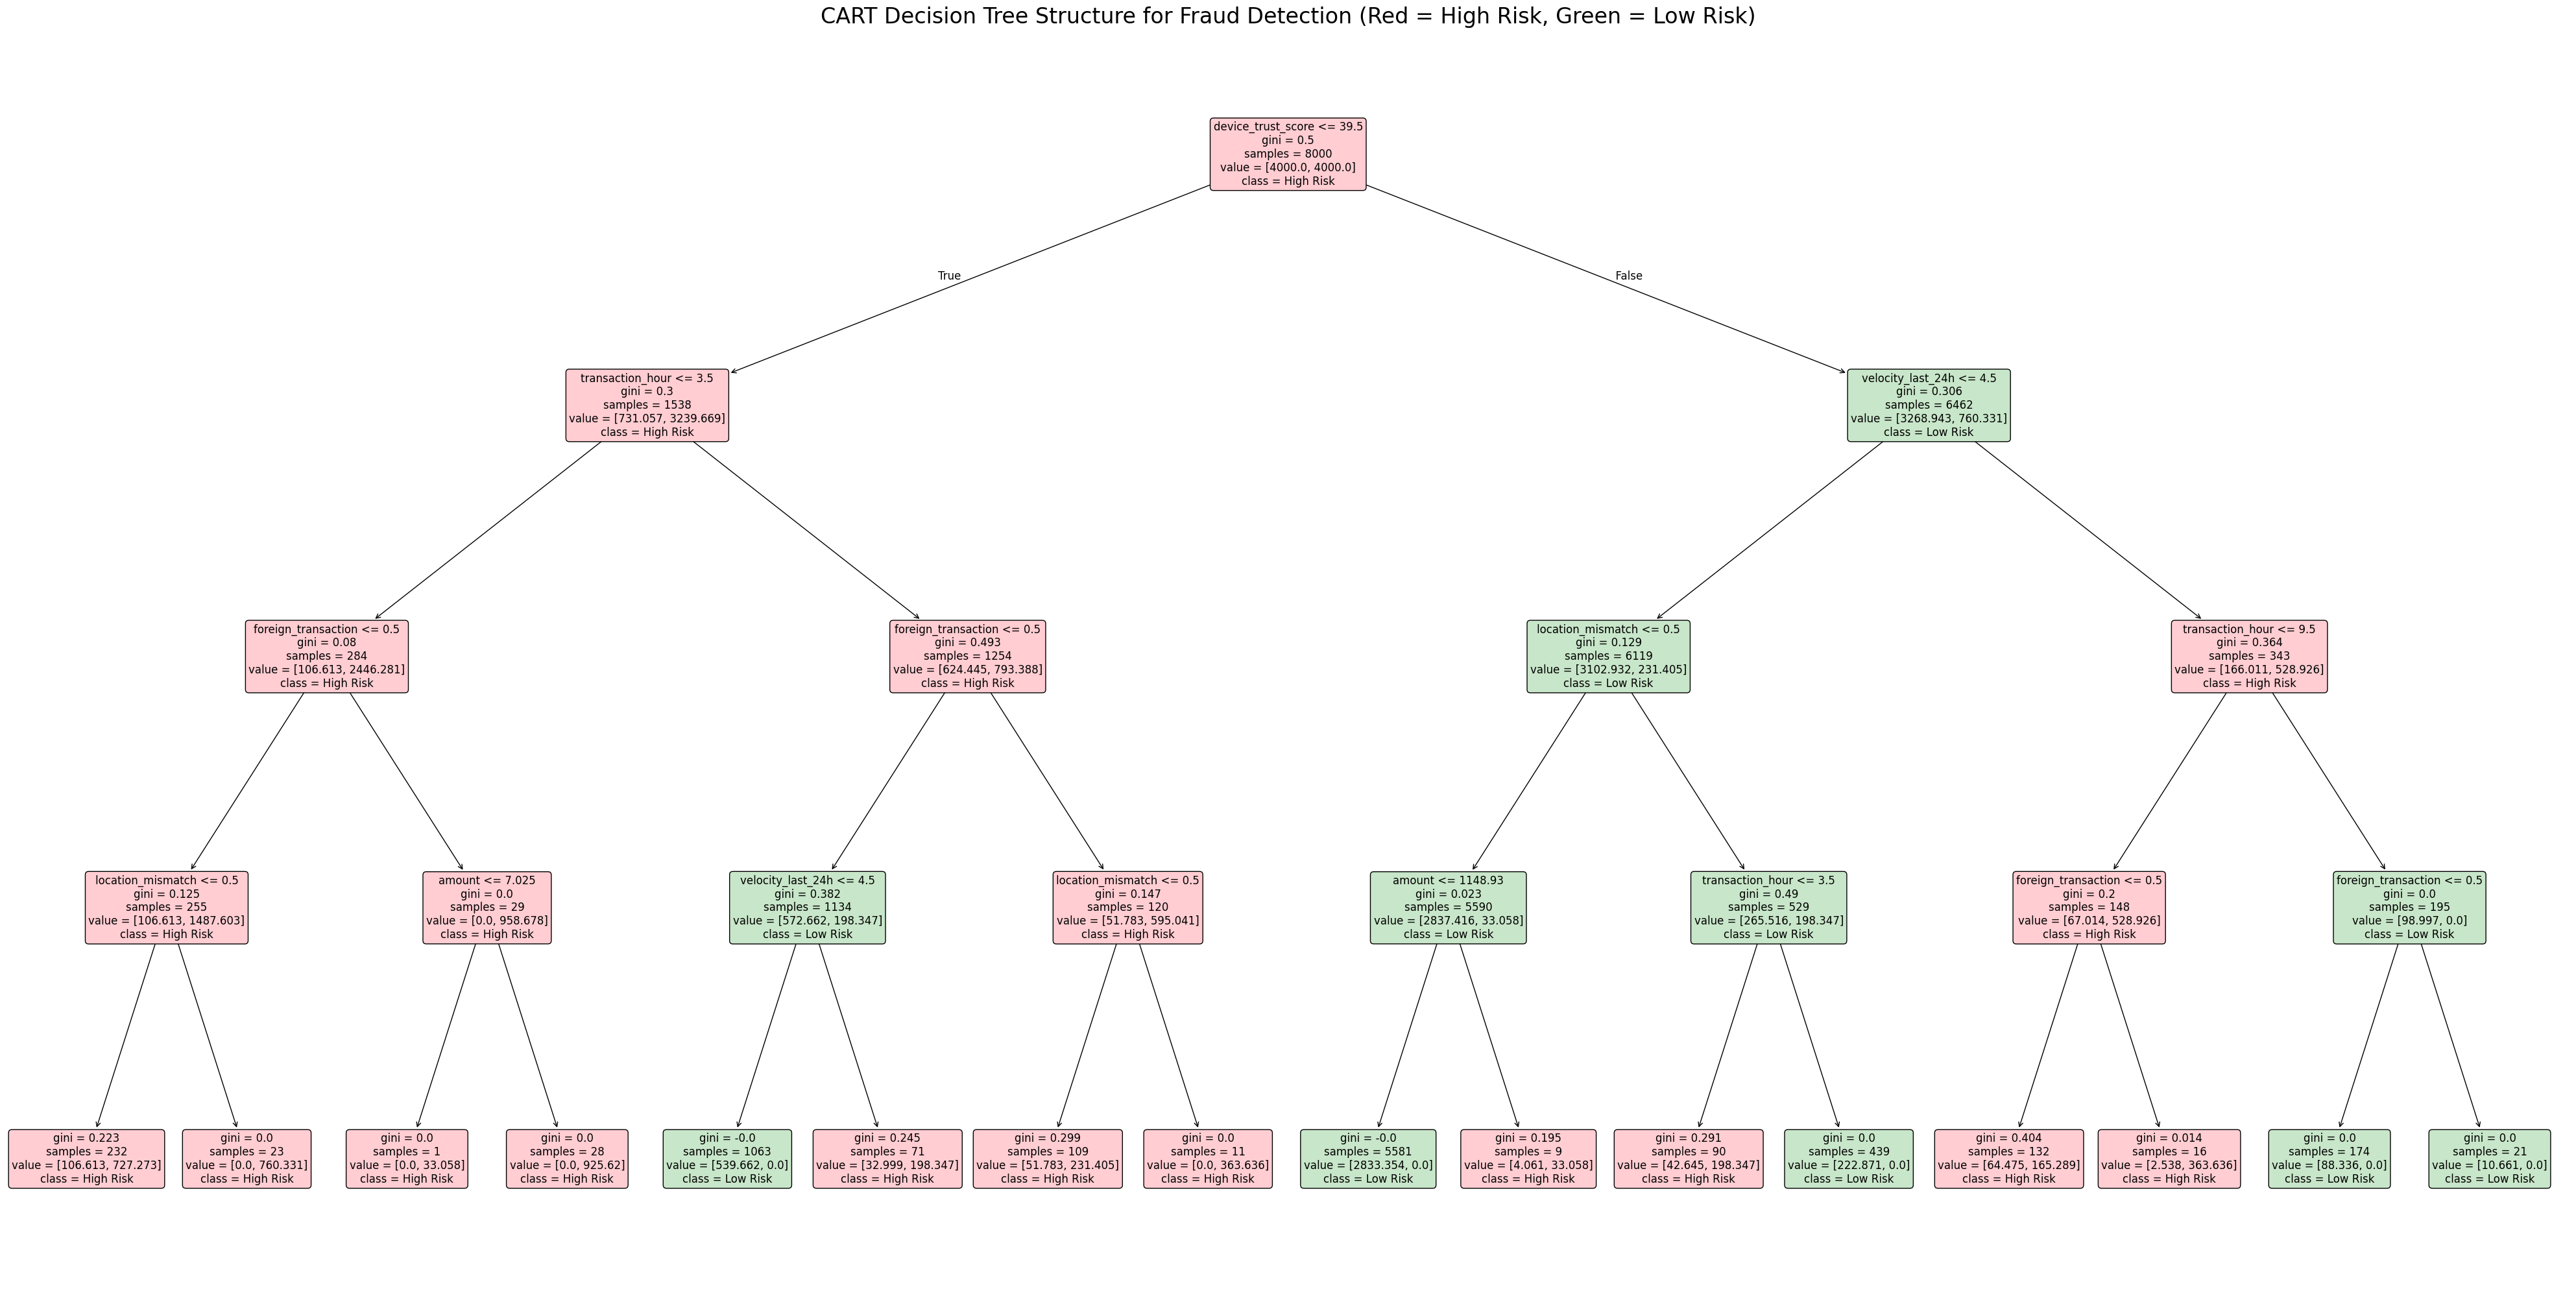

(Clean, non-overlapping tree diagram saved as 'decision_tree_red_green_clean.png' in Colab files)



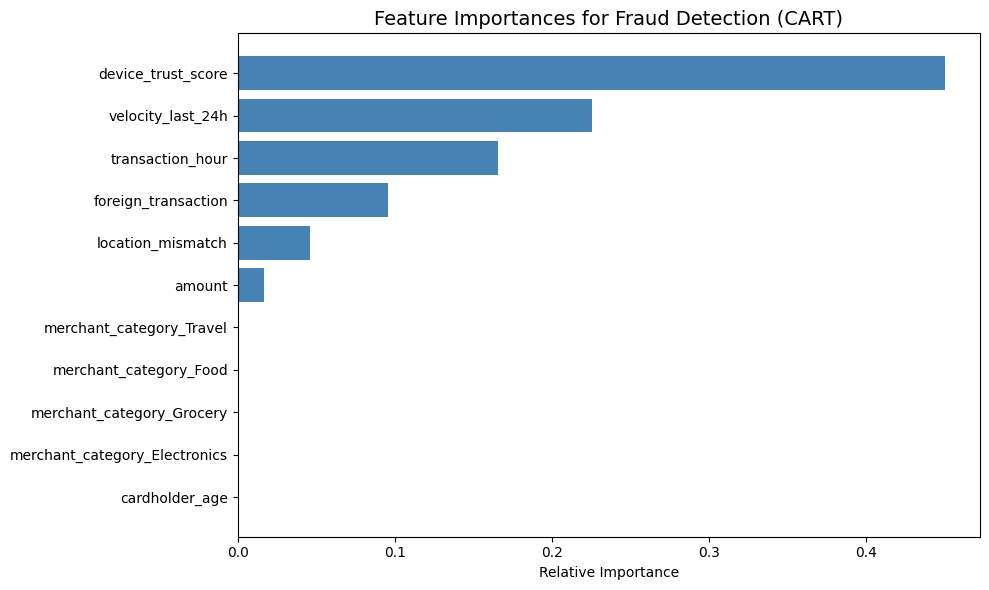

(Feature importances chart saved as 'feature_importances.png' in Colab files)

 METRICS FOR SECTION 6.3 (MODEL COMPARISON TABLE)
Accuracy:  0.9240
Precision: 0.1648
Recall:    1.0000  <-- Prioritize this for fraud!
F1 Score:  0.2830
AUC-ROC:   0.9878

 TOP 3 BUSINESS RULES FOR REPORT SECTION 6.2
Rule 1: IF device_trust_score <= 39.50 AND transaction_hour <= 3.50 AND foreign_transaction > 0.50 AND amount > 7.02
         --> THEN flag as fraud (100.0% probability of fraud)

Rule 2: IF device_trust_score <= 39.50 AND transaction_hour <= 3.50 AND foreign_transaction <= 0.50 AND location_mismatch > 0.50
         --> THEN flag as fraud (100.0% probability of fraud)

Rule 3: IF device_trust_score <= 39.50 AND transaction_hour > 3.50 AND foreign_transaction > 0.50 AND location_mismatch > 0.50
         --> THEN flag as fraud (100.0% probability of fraud)



In [ ]:
# CELL 2: CART Model, Visuals (Non-Overlapping), Feature Importances, and Business Rules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
df = pd.read_csv('credit_card_fraud_10k.csv')

# Drop transaction_id as it has no predictive power
df_clean = df.drop(columns=['transaction_id'])
# One-hot encode the categorical 'merchant_category' column
df_clean = pd.get_dummies(df_clean, columns=['merchant_category'], drop_first=True)

X = df_clean.drop(columns=['is_fraud'])
y = df_clean['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 2. TRAIN THE CART MODEL
# ==========================================
# Requirement fulfilled: DecisionTreeClassifier(max_depth=4, class_weight='balanced')
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# ==========================================
# 3. VISUALISE THE DECISION TREE (RED/GREEN - NON-OVERLAPPING)
# ==========================================
# Requirement fulfilled: Visualise tree, colour code nodes: red = high fraud risk, green = low risk.
# FIX: Increased figsize to (40, 20) and adjusted fontsize to 12 to completely prevent overlapping boxes
fig, ax = plt.subplots(figsize=(40, 20))
tree_plot = plot_tree(dt_model,
                      feature_names=X.columns,
                      class_names=['Low Risk', 'High Risk'],
                      filled=True,
                      rounded=True,
                      fontsize=12,
                      ax=ax)

# Custom loop to apply the exact Red/Green color requirement based on the class outcome
for node in tree_plot:
    text = node.get_text()
    if 'class = High Risk' in text:
        node.get_bbox_patch().set_facecolor('#ffcdd2') # Light Red for High Risk
    elif 'class = Low Risk' in text:
        node.get_bbox_patch().set_facecolor('#c8e6c9') # Light Green for Low Risk

plt.title("CART Decision Tree Structure for Fraud Detection (Red = High Risk, Green = Low Risk)", fontsize=24)
plt.tight_layout()
plt.savefig('decision_tree_red_green_clean.png', dpi=300, bbox_inches='tight') # bbox_inches='tight' trims empty margins
plt.show()
print("(Clean, non-overlapping tree diagram saved as 'decision_tree_red_green_clean.png' in Colab files)\n")

# ==========================================
# 4. FEATURE IMPORTANCES
# ==========================================
# Requirement fulfilled: Extract feature importances and plot bar chart
importances = dt_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances for Fraud Detection (CART)', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=300)
plt.show()
print("(Feature importances chart saved as 'feature_importances.png' in Colab files)\n")

# ==========================================
# 5. EVALUATION METRICS FOR SECTION 6.3
# ==========================================
# Requirement fulfilled: Evaluate on test set (Accuracy, Precision, Recall, F1, AUC-ROC)
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

print("="*60)
print(" METRICS FOR SECTION 6.3 (MODEL COMPARISON TABLE)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}  <-- Prioritize this for fraud!")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*60, "\n")

# ==========================================
# 6. EXTRACT TOP 3 BUSINESS RULES
# ==========================================
# Requirement fulfilled: Translate top 3 tree rules into plain English business rules
def get_top_fraud_rules(tree_model, feature_names, top_n=3):
    tree_ = tree_model.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    paths = []

    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            # Left child
            recurse(tree_.children_left[node], path + [f"{name} <= {threshold:.2f}"])
            # Right child
            recurse(tree_.children_right[node], path + [f"{name} > {threshold:.2f}"])
        else:
            # Leaf node reached
            samples = tree_.n_node_samples[node]
            values = tree_.value[node][0]
            fraud_prob = values[1] / sum(values) # Probability of class 1 (Fraud)
            paths.append((path, fraud_prob, samples))

    recurse(0, [])

    # Sort paths by highest fraud probability, then by most samples affected
    paths.sort(key=lambda x: (x[1], x[2]), reverse=True)

    print("="*60)
    print(f" TOP {top_n} BUSINESS RULES FOR REPORT SECTION 6.2")
    print("="*60)
    for i in range(min(top_n, len(paths))):
        rule_conditions = paths[i][0]
        prob = paths[i][1] * 100

        # Translate to plain english format requested in prompt
        rule_str = " AND ".join(rule_conditions)
        print(f"Rule {i+1}: IF {rule_str}")
        print(f"         --> THEN flag as fraud ({prob:.1f}% probability of fraud)\n")

get_top_fraud_rules(dt_model, X.columns)